In place of our original formulation of the emission

$$ 
\epsilon(t) = e^{kt}  \cdot \epsilon_0 e^{-kt_0} \cdot \frac{e^{3 (t_{p_1}-t)/t_{decarb}}}{1+e^{3(t_{p_1}-t)/t_{decarb}}} \ \ \ \ (1)
$$

$$
t_{p_1} = t_{peak} + {t_{decarb} \over 3} log( {3 \over t_{decarb} k}-1) \ \ \ \ (2)
$$

We'll substitute N for the number 3,

$$ 
\epsilon(t) = e^{kt}  \cdot \epsilon_0 e^{-kt_0} \cdot \frac{e^{N (t_{p_1}-t)/t_{decarb}}}{1+e^{N(t_{p_1}-t)/t_{decarb}}} \ \ \ \ (3)
$$

$$
t_{p_1} = t_{peak} + {t_{decarb} \over N} log( {N \over t_{decarb} k}-1) \ \ \ \ (4)
$$

Then we'll determine the best value of $N$ by plotting the error in the 80/20 decarbonization time

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import meclib.cl as cl
%matplotlib inline

In [3]:
def myepsfun(t_start,t_stop,nsteps,t_peak,t_decarb,k,t_0,eps_0,N=3):
    tp1 = t_peak + (t_decarb/N)*np.log(N/(k*t_decarb)-1)
    myeps = np.exp(k*t) * eps_0*np.exp(-k*t_0) * np.exp(N/t_decarb*(tp1-t)) / (1+np.exp(N/t_decarb*(tp1-t)))
    return t, myeps

Using the 80/20 rule, the best value of N is 2.4


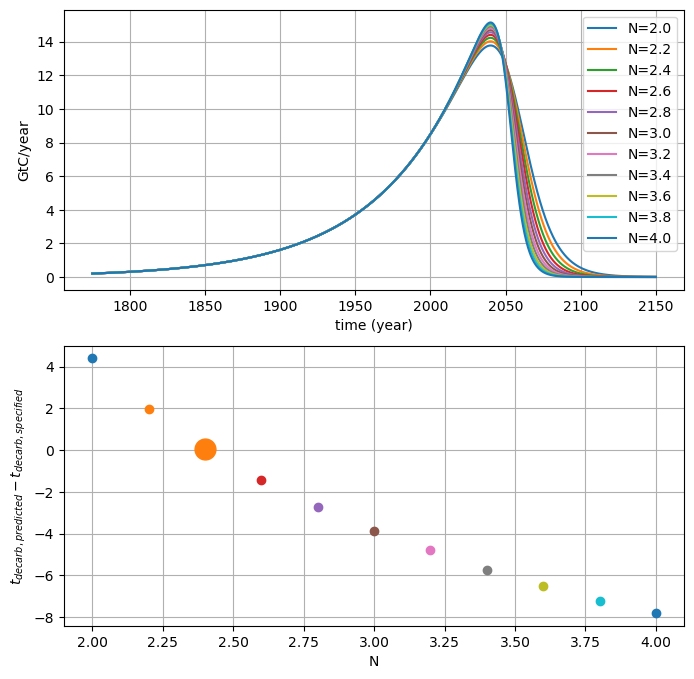

In [4]:
t_start = 1775
t_stop = 2150
nsteps = 2000
t = np.linspace(t_start,t_stop,nsteps)
t_peak = 2040
t_decarb = 20
k = 0.0166
t_0 = 2000
eps_0 = 8.5
Nlist = np.linspace(2,4,11)
plt.figure(figsize=(8,8))
ax1 = plt.subplot(2,1,1)
ax2 = plt.subplot(2,1,2)
upper_boundary = 0.8
lower_boundary = 1-upper_boundary
t_decarb_error_best = 100
N_best = 100

for N_exact in Nlist:
    
    N = np.round(N_exact,2)
    t, myeps = myepsfun(t_start,t_stop,nsteps,t_peak,t_decarb,k,t_0,eps_0,N=N)
    ax1.plot(t,myeps,label='N='+str(N))
    
    # Finding the 80/20 times
    index_of_peak = np.argmin(np.abs(t-t_peak))
    epsmax = myeps[index_of_peak]; #print(epsmax)
    index_of_80 = np.argmin(np.abs(myeps[index_of_peak:]-epsmax*upper_boundary))+index_of_peak
    index_of_20 = np.argmin(np.abs(myeps[index_of_peak:]-epsmax*lower_boundary))+index_of_peak
    t_decarb_obs = t[index_of_20]-t[index_of_80]
    t_decarb_error = t_decarb_obs-t_decarb
    ax2.plot(N,t_decarb_error,'o')
    
    if np.abs(t_decarb_error) <= t_decarb_error_best:
        t_decarb_error_best = np.abs(t_decarb_error)
        N_best = N
    
ax1.set_xlabel('time (year)')
ax1.set_ylabel('GtC/year')
ax1.legend()
ax1.grid(True)
ax2.set_xlabel('N')
ax2.set_ylabel('$t_{decarb,predicted} - t_{decarb,specified}$')
ax2.grid(True)
ax2.plot(N_best,t_decarb_error_best,'o',markersize=15)
print('Using the 80/20 rule, the best value of N is',N_best)

Using the 85/15 rule, the best value of N is 3.0


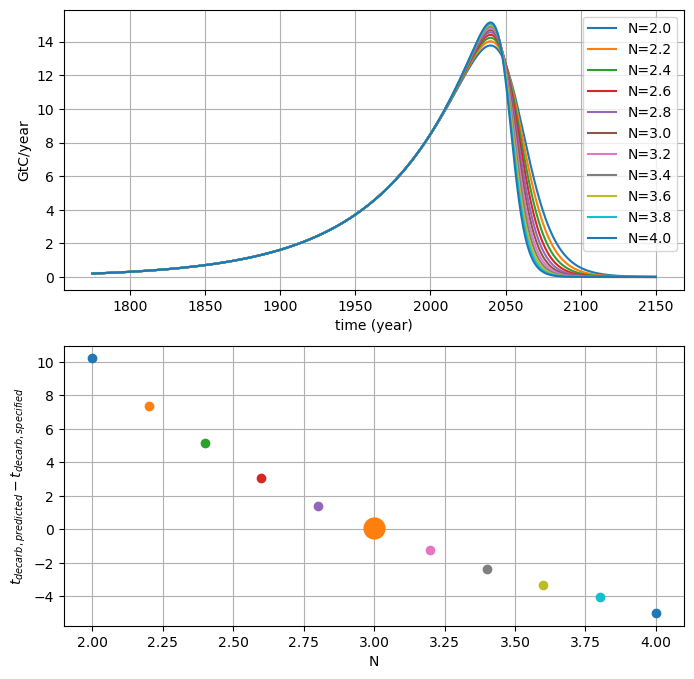

In [5]:
t_start = 1775
t_stop = 2150
nsteps = 2000
t = np.linspace(t_start,t_stop,nsteps)
t_peak = 2040
t_decarb = 20
k = 0.0166
t_0 = 2000
eps_0 = 8.5
Nlist = np.linspace(2,4,11)
plt.figure(figsize=(8,8))
ax1 = plt.subplot(2,1,1)
ax2 = plt.subplot(2,1,2)
upper_boundary = 0.85
lower_boundary = 1-upper_boundary
t_decarb_error_best = 100
N_best = 100

for N_exact in Nlist:
    
    N = np.round(N_exact,2)
    t, myeps = myepsfun(t_start,t_stop,nsteps,t_peak,t_decarb,k,t_0,eps_0,N=N)
    ax1.plot(t,myeps,label='N='+str(N))
    
    # Finding the 80/20 times
    index_of_peak = np.argmin(np.abs(t-t_peak))
    epsmax = myeps[index_of_peak]; #print(epsmax)
    index_of_80 = np.argmin(np.abs(myeps[index_of_peak:]-epsmax*upper_boundary))+index_of_peak
    index_of_20 = np.argmin(np.abs(myeps[index_of_peak:]-epsmax*lower_boundary))+index_of_peak
    t_decarb_obs = t[index_of_20]-t[index_of_80]
    t_decarb_error = t_decarb_obs-t_decarb
    ax2.plot(N,t_decarb_error,'o')
    
    if np.abs(t_decarb_error) <= t_decarb_error_best:
        t_decarb_error_best = np.abs(t_decarb_error)
        N_best = N
    
ax1.set_xlabel('time (year)')
ax1.set_ylabel('GtC/year')
ax1.legend()
ax1.grid(True)
ax2.set_xlabel('N')
ax2.set_ylabel('$t_{decarb,predicted} - t_{decarb,specified}$')
ax2.grid(True)
ax2.plot(N_best,t_decarb_error_best,'o',markersize=15)
print('Using the 85/15 rule, the best value of N is',N_best)